<a href="https://colab.research.google.com/github/rishi-analytics/sql-for-data-science-usda-production-analysis/blob/main/notebook/USDA_production_datasets_SQL_final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#USDA production datasets SQL final project
This notebook loads USDA CSV datasets into a SQLite database, cleans numeric fields, and answers the final project SQL questions. The workflow is fully reproducible and saved to Google Drive for GitHub documentation.

##Establishing Setup for SQLite integration in Python

In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
import os
import sqlite3
import pandas as pd

project_dir = "/content/drive/MyDrive/SQL_course"
data_dir = project_dir   # since CSV files are directly inside SQL_course
db_path = os.path.join(project_dir, "usda.sqlite")

print("Project dir:", project_dir)
print("Files in project dir:", os.listdir(project_dir))

Project dir: /content/drive/MyDrive/SQL_course
Files in project dir: ['cheese_production.csv', 'honey_production.csv', 'milk_production.csv', 'coffee_production.csv', 'egg_production.csv', 'state_lookup.csv', 'yogurt_production.csv']


In [6]:
import pandas as pd
import os

csv_files = {
    "cheese_production": "cheese_production.csv",
    "honey_production": "honey_production.csv",
    "milk_production": "milk_production.csv",
    "coffee_production": "coffee_production.csv",
    "egg_production": "egg_production.csv",
    "yogurt_production": "yogurt_production.csv",
    "state": "state_lookup.csv",
}

dfs = {}
for table, filename in csv_files.items():
    path = os.path.join(project_dir, filename)
    df = pd.read_csv(path)
    dfs[table] = df
    print(table, df.shape)
    display(df.head(3))

cheese_production (7488, 7)


,Year,Period,Geo_Level,State_ANSI,Commodity_ID,Domain,Value
0,2023,APR,STATE,6.0,6,TOTAL,"208,807,000"
1,2023,APR,STATE,16.0,6,TOTAL,"86,452,000"
2,2023,APR,STATE,17.0,6,TOTAL,"5,068,000"


honey_production (1559, 5)


,Year,Geo_Level,State_ANSI,Commodity_ID,Value
0,2022,STATE,1.0,2,"400,000"
1,2022,STATE,4.0,2,"1,035,000"
2,2022,STATE,5.0,2,"1,120,000"


milk_production (37638, 7)


...

,Year,Period,Geo_Level,State_ANSI,Commodity_ID,Value
0,2023,APR,STATE,1.0,7,"224,100,000"
1,2023,APR,STATE,5.0,7,"319,000,000"
2,2023,APR,STATE,6.0,7,"271,300,000"


yogurt_production (149, 7)


,Year,Period,Geo_Level,State_ANSI,Commodity_ID,Domain,Value
0,2022,YEAR,STATE,6,4,TOTAL,"377,839,000"
1,2022,YEAR,STATE,36,4,TOTAL,"793,256,000"
2,2021,YEAR,STATE,6,4,TOTAL,"374,637,000"


state (50, 2)


,State,State_ANSI
0,ALABAMA,1
1,ALASKA,2
2,ARIZONA,4


Creating tables for the dataset.

In [7]:
import sqlite3

db_path = os.path.join(project_dir, "usda.sqlite")
conn = sqlite3.connect(db_path)
cur = conn.cursor()

cur.execute("PRAGMA foreign_keys = ON;")
print("Connected to SQLite DB:", db_path)

Connected to SQLite DB: /content/drive/MyDrive/SQL_course/usda.sqlite


In [9]:
create_tables_sql = """
CREATE TABLE cheese_production (
    Year INTEGER,
    Period TEXT,
    Geo_Level TEXT,
    State_ANSI INTEGER,
    Commodity_ID INTEGER,
    Domain TEXT,
    Value INTEGER
);

CREATE TABLE honey_production (
    Year INTEGER,
    Geo_Level TEXT,
    State_ANSI INTEGER,
    Commodity_ID INTEGER,
    Value INTEGER
);

CREATE TABLE milk_production (
    Year INTEGER,
    Period TEXT,
    Geo_Level TEXT,
    State_ANSI INTEGER,
    Commodity_ID INTEGER,
    Domain TEXT,
    Value INTEGER
);

CREATE TABLE coffee_production (
    Year INTEGER,
    Period TEXT,
    Geo_Level TEXT,
    State_ANSI INTEGER,
    Commodity_ID INTEGER,
    Value INTEGER
);

CREATE TABLE egg_production (
    Year INTEGER,
    Period TEXT,
    Geo_Level TEXT,
    State_ANSI INTEGER,
    Commodity_ID INTEGER,
    Value INTEGER
);

CREATE TABLE state_lookup (
    State TEXT,
    State_ANSI INTEGER
);

CREATE TABLE yogurt_production (
    Year INTEGER,
    Period TEXT,
    Geo_Level TEXT,
    State_ANSI INTEGER,
    Commodity_ID INTEGER,
    Domain TEXT,
    Value INTEGER
);
"""
cur.executescript(create_tables_sql)
conn.commit()

pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;",
    conn
)

,name
0,cheese_production
1,coffee_production
2,egg_production
3,honey_production
4,milk_production
5,state_lookup
6,yogurt_production


Import CSV data into those tables

In [10]:
# Step 1
for table, df in dfs.items():
    target = "state_lookup" if table == "state" else table
    df.to_sql(target, conn, if_exists="append", index=False)

print("Import complete")

Import complete


Verify row counts

In [11]:
# Step 2
tables = [
    "cheese_production",
    "coffee_production",
    "egg_production",
    "honey_production",
    "milk_production",
    "state_lookup",
    "yogurt_production",
]

for t in tables:
    display(pd.read_sql_query(f"SELECT '{t}' AS table_name, COUNT(*) AS rows FROM {t};", conn))

,table_name,rows
0,cheese_production,7488


,table_name,rows
0,coffee_production,71


,table_name,rows
0,egg_production,6327


,table_name,rows
0,honey_production,1559


,table_name,rows
0,milk_production,37638


,table_name,rows
0,state_lookup,50


,table_name,rows
0,yogurt_production,149


Clean the Value column commas

In [12]:
# Step 3
production_tables = [
    "cheese_production",
    "honey_production",
    "milk_production",
    "coffee_production",
    "egg_production",
    "yogurt_production",
]

for t in production_tables:
    cur.execute(f"UPDATE {t} SET Value = REPLACE(Value, ',', '')")

conn.commit()
print("Value cleanup complete")

Value cleanup complete


##1.0 Starting Analysis With Practice Questions

Moving from setup to analysis

The database is now created, the USDA CSV files are loaded into SQLite tables, and the numeric value fields have been cleaned. The next step is to answer the practice questions using SQL queries and record the results directly in this notebook. Each question below includes a short description, a single query, and a result table output.

Practice Question 1

Find the total milk production for the year 2023.

In [14]:
def run_sql(query: str):
    return pd.read_sql_query(query, conn)

In [15]:
q1 = """
SELECT SUM(CAST(Value AS REAL)) AS total_milk_production_2023
FROM milk_production
WHERE Year = 2023;
"""
run_sql(q1)

,total_milk_production_2023
0,9.181200e+10


Practice Question 2

Show coffee production data for the year 2015. What is the total value?

In [18]:
data = """
SELECT *
FROM coffee_production
WHERE Year = 2015;
"""
run_sql(data)

,Year,Period,Geo_Level,State_ANSI,Commodity_ID,Value
0,2015,YEAR,STATE,15,1,6600000


Practice Question 3

Find the average honey production for the year 2022.

In [19]:
q3 = """
SELECT AVG(CAST(Value AS REAL)) AS avg_honey_production_2022
FROM honey_production
WHERE Year = 2022;
"""
run_sql(q3)

,avg_honey_production_2022
0,3133275.0


Practice Question 4

Get the state names with their corresponding ANSI codes from the state_lookup table. What number is Iowa?

In [20]:
q4_list = """
SELECT State, State_ANSI
FROM state_lookup
ORDER BY State;
"""
run_sql(q4_list)

,State,State_ANSI
0,ALABAMA,1
1,ALASKA,2
2,ARIZONA,4
3,ARKANSAS,5
4,CALIFORNIA,6
5,COLORADO,8
6,CONNECTICUT,9
7,DELAWARE,10
8,FLORIDA,12
9,GEORGIA,13


Practice Question 5

Find the highest yogurt production value for the year 2022.

In [21]:
q5 = """
SELECT MAX(CAST(Value AS REAL)) AS max_yogurt_production_2022
FROM yogurt_production
WHERE Year = 2022;
"""
run_sql(q5)

,max_yogurt_production_2022
0,793256000.0


Practice Question 6

Find states where both honey and milk were produced in 2022. Did State_ANSI 35 produce both honey and milk in 2022?

In [25]:
q6_states = """
SELECT DISTINCT h.State_ANSI
FROM honey_production h
JOIN milk_production m
ON h.State_ANSI = m.State_ANSI
WHERE h.Year = 2022 AND m.Year = 2022
ORDER BY h.State_ANSI;
"""
run_sql(q6_states)


,State_ANSI
0,1
1,4
2,5
3,6
4,8
5,12
6,13
7,16
8,17
9,18


In [24]:
q6_check_35 = """
SELECT
  CASE
    WHEN EXISTS (
      SELECT 1
      FROM honey_production h
      JOIN milk_production m
      ON h.State_ANSI = m.State_ANSI
      WHERE h.Year = 2022 AND m.Year = 2022 AND h.State_ANSI = 35
    )
    THEN 'Yes'
    ELSE 'No'
  END AS produced_both_in_2022;
"""
run_sql(q6_check_35)

,produced_both_in_2022
0,No


In [26]:
q7 = """
SELECT SUM(CAST(y.Value AS REAL)) AS total_yogurt_for_cheese_states_2022
FROM yogurt_production y
WHERE y.Year = 2022
AND y.State_ANSI IN (
    SELECT DISTINCT State_ANSI
    FROM cheese_production
    WHERE Year = 2022
);
"""
run_sql(q7)

,total_yogurt_for_cheese_states_2022
0,1.171095e+09


##2.0 Real World Business Case

**Scenario and Analytical Objective**


Role and Context

As a Data Scientist at the United States Department of Agriculture, I am responsible for analyzing agricultural production data across multiple states and years. The goal of this analysis is to generate insights that can support strategic planning, policy decisions, and resource allocation.

The datasets available for this project include:

* milk_production

* cheese_production

* coffee_production

* honey_production

* yogurt_production

* state_lookup

These datasets track production levels across states and years, allowing for both cross sectional and time series analysis.

**Analytical Objectives**

In this project, I aim to:

* Assess production levels state by state for each commodity

* Identify year over year trends

* Detect anomalies or unusual patterns

* Understand relationships across commodities

* Provide data backed insights that could guide decision making

**This Business Case analysis will cover analysis aim to answer the questions given in the graded assigment.**

1 Overall Production by Commodity

As an initial step, I want to understand the overall production scale of each commodity across all available years.

In [27]:
commodity_totals = """
SELECT 'milk' AS commodity, SUM(CAST(Value AS REAL)) AS total_value FROM milk_production
UNION ALL
SELECT 'cheese', SUM(CAST(Value AS REAL)) FROM cheese_production
UNION ALL
SELECT 'coffee', SUM(CAST(Value AS REAL)) FROM coffee_production
UNION ALL
SELECT 'honey', SUM(CAST(Value AS REAL)) FROM honey_production
UNION ALL
SELECT 'yogurt', SUM(CAST(Value AS REAL)) FROM yogurt_production;
"""
run_sql(commodity_totals)

,commodity,total_value
0,milk,2.551840e+13
1,cheese,7.196206e+11
2,coffee,4.612070e+08
3,honey,6.464032e+09
4,yogurt,2.604827e+10


Interpretation: Overall Commodity Production

Based on the aggregated totals:

Milk production is significantly larger than all other commodities, exceeding 25 trillion in total output.

Cheese production follows, but at a much smaller scale relative to milk.

Yogurt production, while dairy related, remains substantially below milk and cheese.

Honey production is moderate.

Coffee production is the smallest among the listed commodities.

As a Data Scientist at USDA, this immediately signals that dairy, particularly milk, represents the dominant segment of production volume. This suggests that policy, forecasting, and risk management efforts should prioritize milk-related supply chain considerations due to its economic magnitude.

**Graded Assignment Questions**


Question 1

The manager needs the total milk production for 2023 for the yearly report.

In [28]:
q1 = """
SELECT SUM(CAST(Value AS REAL)) AS total_milk_production_2023
FROM milk_production
WHERE Year = 2023;
"""
run_sql(q1)

,total_milk_production_2023
0,9.181200e+10


Question 2

The Cheese Department wants to know which states had cheese production greater than 100 million in April 2023. The deliverable is the number of states.

Assumption: “April 2023” means Year = 2023 and Period = 'APR' or Period contains April. Most USDA monthly datasets store April as APR. First I will list states, then count them.

In [29]:
q2_list = """
SELECT DISTINCT s.State, cp.State_ANSI
FROM cheese_production cp
JOIN state_lookup s
ON cp.State_ANSI = s.State_ANSI
WHERE cp.Year = 2023
AND cp.Period = 'APR'
AND CAST(cp.Value AS REAL) > 100000000
ORDER BY s.State;
"""
run_sql(q2_list)

,State,State_ANSI
0,CALIFORNIA,6
1,WISCONSIN,55


In [30]:
q2_count = """
SELECT COUNT(DISTINCT cp.State_ANSI) AS num_states
FROM cheese_production cp
WHERE cp.Year = 2023
AND cp.Period = 'APR'
AND CAST(cp.Value AS REAL) > 100000000;
"""
run_sql(q2_count)

,num_states
0,2


Question 3

The manager wants to understand how coffee production has changed over the years. First, I will retrieve total coffee production for 2011.

In [31]:
q3 = """
SELECT SUM(CAST(Value AS REAL)) AS total_coffee_production_2011
FROM coffee_production
WHERE Year = 2011;
"""
run_sql(q3)

,total_coffee_production_2011
0,7600000.0


Question 4

There's a meeting with the Honey Council next week. Find the average honey production for 2022 so you're prepared.

In [32]:
q4 = """
SELECT AVG(CAST(Value AS REAL)) AS avg_honey_production_2022
FROM honey_production
WHERE Year = 2022;
"""
run_sql(q4)

,avg_honey_production_2022
0,3133275.0


Question 5
The State Relations team wants a list of all states names with their corresponding ANSI codes. Can you generate that list?

What is the State_ANSI code for Florida?

In [33]:
q5_list = """
SELECT State, State_ANSI
FROM state_lookup
ORDER BY State;
"""
run_sql(q5_list)

,State,State_ANSI
0,ALABAMA,1
1,ALASKA,2
2,ARIZONA,4
3,ARKANSAS,5
4,CALIFORNIA,6
5,COLORADO,8
6,CONNECTICUT,9
7,DELAWARE,10
8,FLORIDA,12
9,GEORGIA,13


In [35]:
q5_florida = """
SELECT State_ANSI
FROM state_lookup
WHERE State = 'FLORIDA';
"""
run_sql(q5_florida)

,State_ANSI
0,12


Question 6

For a cross-commodity report, can you list all states with their cheese production values, even if they didn't produce any cheese in April of 2023?

What is the total for NEW JERSEY?

In [40]:
q6_list = """
SELECT
  s.State,
  COALESCE(SUM(CAST(cp.Value AS REAL)), 0) AS cheese_value_apr_2023
FROM state_lookup s
LEFT JOIN cheese_production cp
  ON s.State_ANSI = cp.State_ANSI
  AND cp.Year = 2023
  AND cp.Period = 'APR'
GROUP BY s.State
HAVING s.State = 'NEW JERSEY'
ORDER BY s.State;
"""
run_sql(q6_list)

,State,cheese_value_apr_2023
0,NEW JERSEY,4889000.0


Question 7

Can you find the total yogurt production for states in the year 2022 which also have cheese production data from 2023? This will help the Dairy Division in their planning.

In [41]:
q7 = """
SELECT SUM(CAST(y.Value AS REAL)) AS total_yogurt_2022_for_cheese_states_2023
FROM yogurt_production y
WHERE y.Year = 2022
AND y.State_ANSI IN (
  SELECT DISTINCT State_ANSI
  FROM cheese_production
  WHERE Year = 2023
);
"""
run_sql(q7)

,total_yogurt_2022_for_cheese_states_2023
0,1.171095e+09


Question 8

List all states from state_lookup that are missing from milk_production in 2023.

How many states are there?

In [42]:
q8_list = """
SELECT s.State, s.State_ANSI
FROM state_lookup s
LEFT JOIN (
  SELECT DISTINCT State_ANSI
  FROM milk_production
  WHERE Year = 2023
) m
ON s.State_ANSI = m.State_ANSI
WHERE m.State_ANSI IS NULL
ORDER BY s.State;
"""
run_sql(q8_list)

,State,State_ANSI
0,ALABAMA,1
1,ALASKA,2
2,ARKANSAS,5
3,CONNECTICUT,9
4,DELAWARE,10
5,HAWAII,15
6,KENTUCKY,21
7,LOUISIANA,22
8,MAINE,23
9,MARYLAND,24


In [43]:
q8_count = """
SELECT COUNT(*) AS num_missing_states
FROM (
  SELECT s.State_ANSI
  FROM state_lookup s
  LEFT JOIN (
    SELECT DISTINCT State_ANSI
    FROM milk_production
    WHERE Year = 2023
  ) m
  ON s.State_ANSI = m.State_ANSI
  WHERE m.State_ANSI IS NULL
);
"""
run_sql(q8_count)

,num_missing_states
0,26


Question 9

List all states with their cheese production values, including states that didn't produce any cheese in April 2023.

Did Delaware produce any cheese in April 2023?

In [44]:
q9_list = """
SELECT
  s.State,
  COALESCE(SUM(CAST(cp.Value AS REAL)), 0) AS cheese_value_apr_2023
FROM state_lookup s
LEFT JOIN cheese_production cp
  ON s.State_ANSI = cp.State_ANSI
  AND cp.Year = 2023
  AND cp.Period = 'APR'
GROUP BY s.State
ORDER BY s.State;
"""
run_sql(q9_list)

,State,cheese_value_apr_2023
0,ALABAMA,0.0
1,ALASKA,0.0
2,ARIZONA,0.0
3,ARKANSAS,0.0
4,CALIFORNIA,208807000.0
5,COLORADO,0.0
6,CONNECTICUT,0.0
7,DELAWARE,0.0
8,FLORIDA,0.0
9,GEORGIA,0.0


Question 10

Find the average coffee production for all years where the honey production exceeded 1 million.

In [45]:
q10 = """
WITH honey_years AS (
  SELECT Year
  FROM honey_production
  GROUP BY Year
  HAVING SUM(CAST(Value AS REAL)) > 1000000
),
coffee_by_year AS (
  SELECT Year, SUM(CAST(Value AS REAL)) AS total_coffee
  FROM coffee_production
  GROUP BY Year
)
SELECT AVG(c.total_coffee) AS avg_coffee_for_honey_gt_1m_years
FROM coffee_by_year c
JOIN honey_years h
ON c.Year = h.Year;
"""
run_sql(q10)

,avg_coffee_for_honey_gt_1m_years
0,6.426667e+06


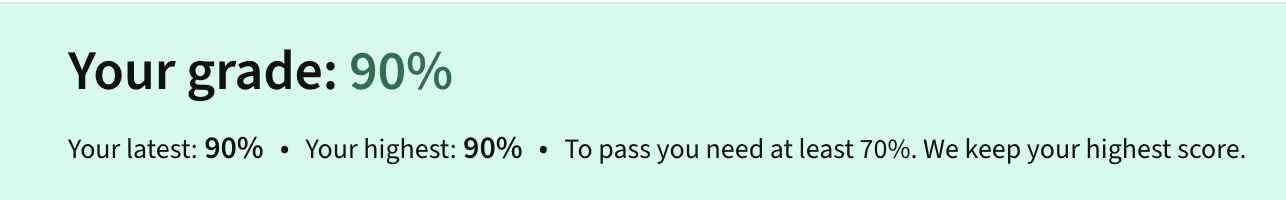

## Final Reflection and Key Takeaways

###Project Completion Summary

In this project, I worked as a Data Scientist at the United States Department of Agriculture, analyzing multi-year production datasets across several agricultural commodities, including milk, cheese, coffee, honey, and yogurt.

I successfully:

- Designed and implemented a SQLite database in Google Colab  
- Imported and structured multiple raw CSV datasets  
- Cleaned and standardized numeric production values  
- Wrote SQL queries to answer operational and strategic business questions  
- Applied joins, aggregations, subqueries, filtering, and grouping logic  
- Generated data-backed insights to support planning discussions  

---

###Technical Skills Demonstrated

Through this project, I applied and strengthened the following skills:

- SQL aggregations (`SUM`, `AVG`, `MAX`)
- Filtering with `WHERE` and `HAVING`
- `GROUP BY` analysis
- `INNER JOIN` and `LEFT JOIN`
- Subqueries and Common Table Expressions (CTEs)
- NULL handling and `COALESCE`
- Data cleaning using SQL functions
- SQLite integration within Python
- Structured analytical documentation in notebook format

---

###Analytical Insight

The analysis revealed that milk production dominates overall agricultural output by a substantial margin. Dairy-related commodities show regional specialization patterns, and cross-commodity analysis highlights states with overlapping production strengths.

These findings demonstrate how structured SQL analysis can support resource allocation, marketing strategies, and long-term agricultural planning.

---

###Final Note

This project represents not only the completion of the **SQL for Data Science** course, but also the successful execution of a full end-to-end data analysis workflow using real-world datasets.

All analysis was conducted using SQLite integrated within Python, with full reproducibility and clear documentation.

This project reflects my ability to translate raw data into structured insights using SQL in a practical business context.